# This notebook contains the visualisation of hyperparameters based on the validation metric used. 
1. Input is the directory storing the validation_metric and hyperparamters
2. Output is a scatter plot, where the x-axis is the learning_rates, y-axis is the initializations, and the sizes of the dots are the average validation_metric value.
3. 

Specifically, the hyperparameters are stored in 

    project/43_estimation_results/hyperparameters_{l}.csv

for $l=0,1,...$.  It contains the learning_rate values (first half of the columns) and the initialization values (second half of the columns).

The validation_metric values are stored in 

    project/43_estimation_results/validation_metric_hyperparam_{l}_feature_{j}.csv

for $j=0,1,2$.  It contains the validation metric over different data sets, but the important quantity is the last row, which contains the average validation metric value over all data sets.

Hyperparam | Ave metric | Median metric
0 0.1060581320367335 0.0217965913758308
1 0.1005771292809787 0.0134989897920653
2 0.1186063389552488 0.0398751082074255
3 0.0988624932492358 0.0119992443507266
4 0.0987748751003817 0.0122995896362846
5 0.1044014871216504 0.0181833599699688
6 0.0982178095605815 0.0117919366133042
7 0.0983259266534038 0.0117289966315979
8 0.1002862621956511 0.0146086340208372


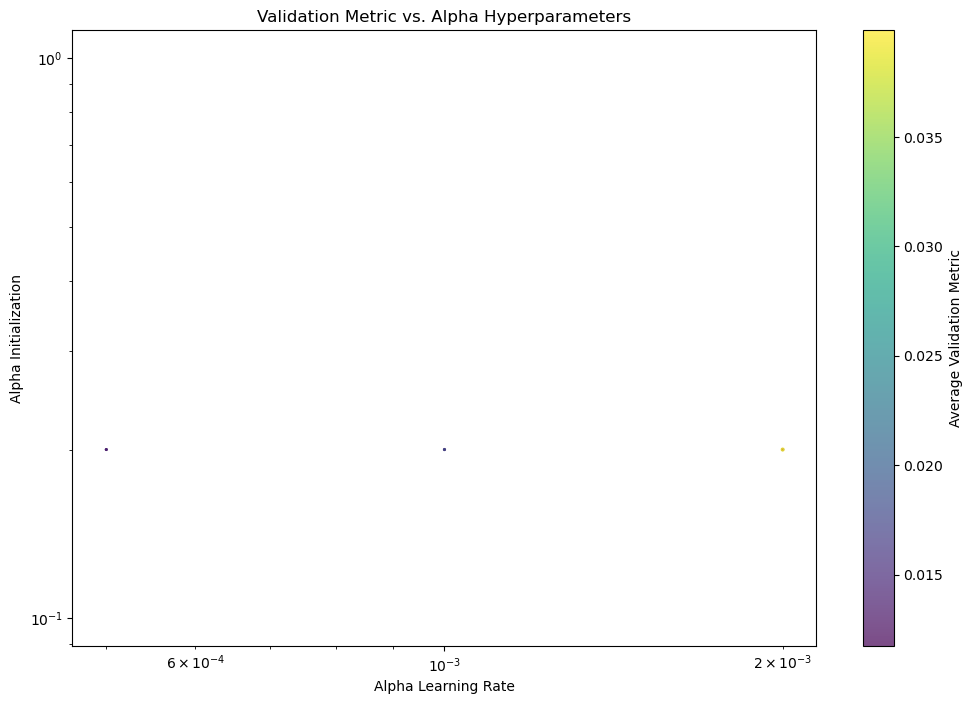

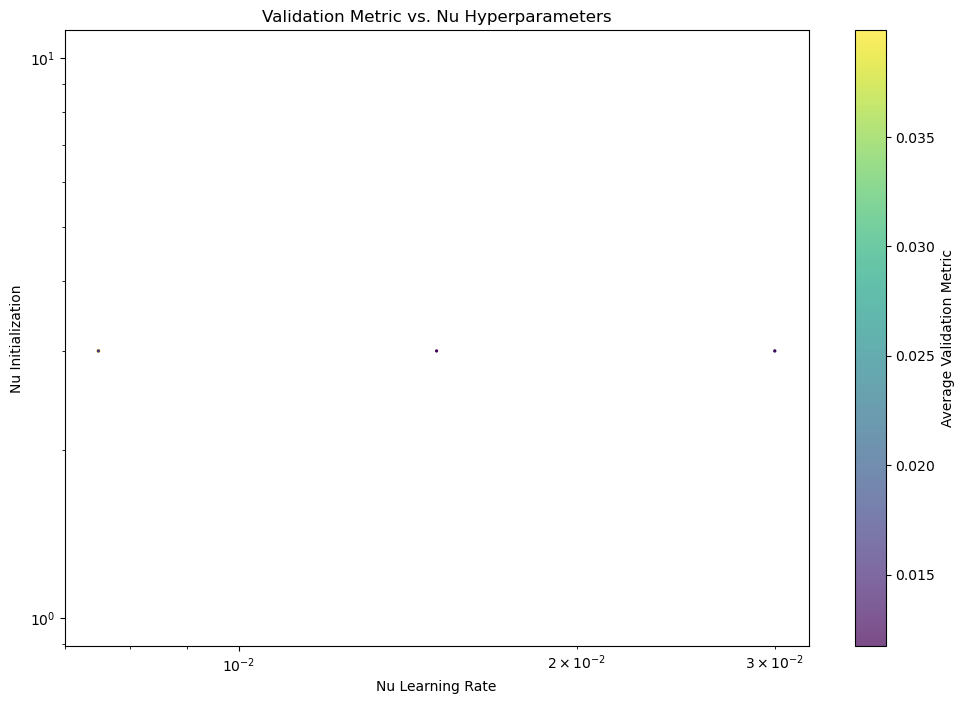

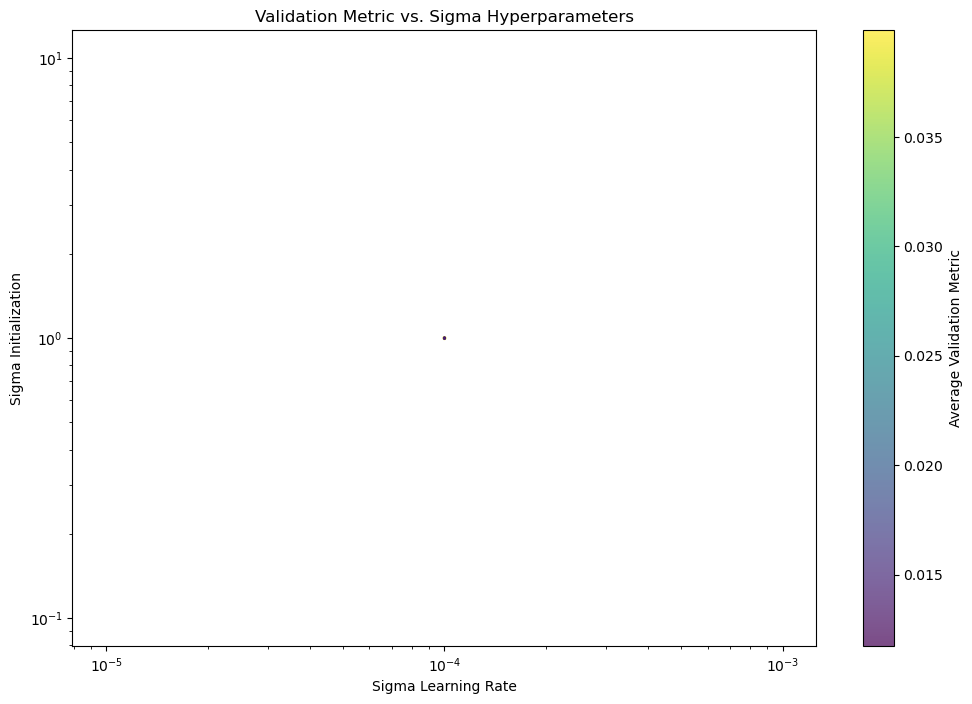

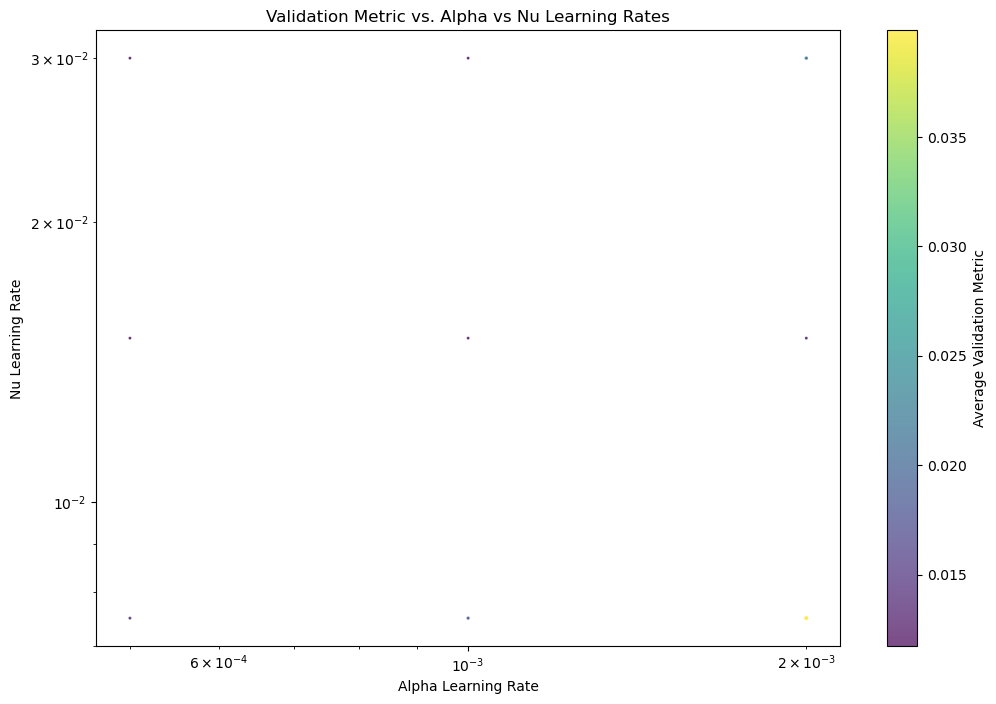

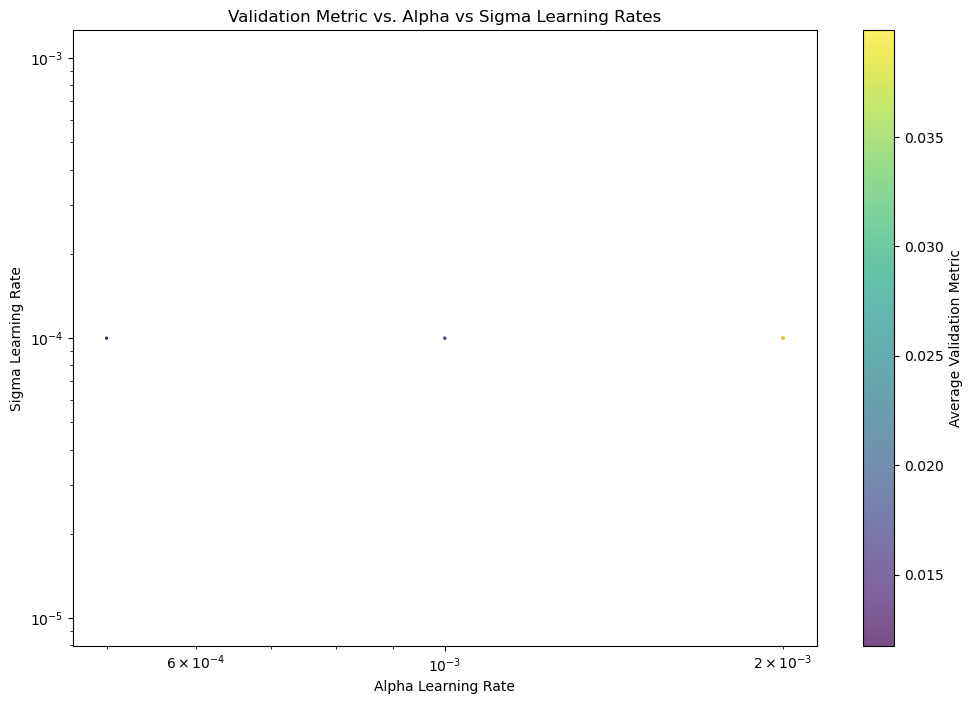

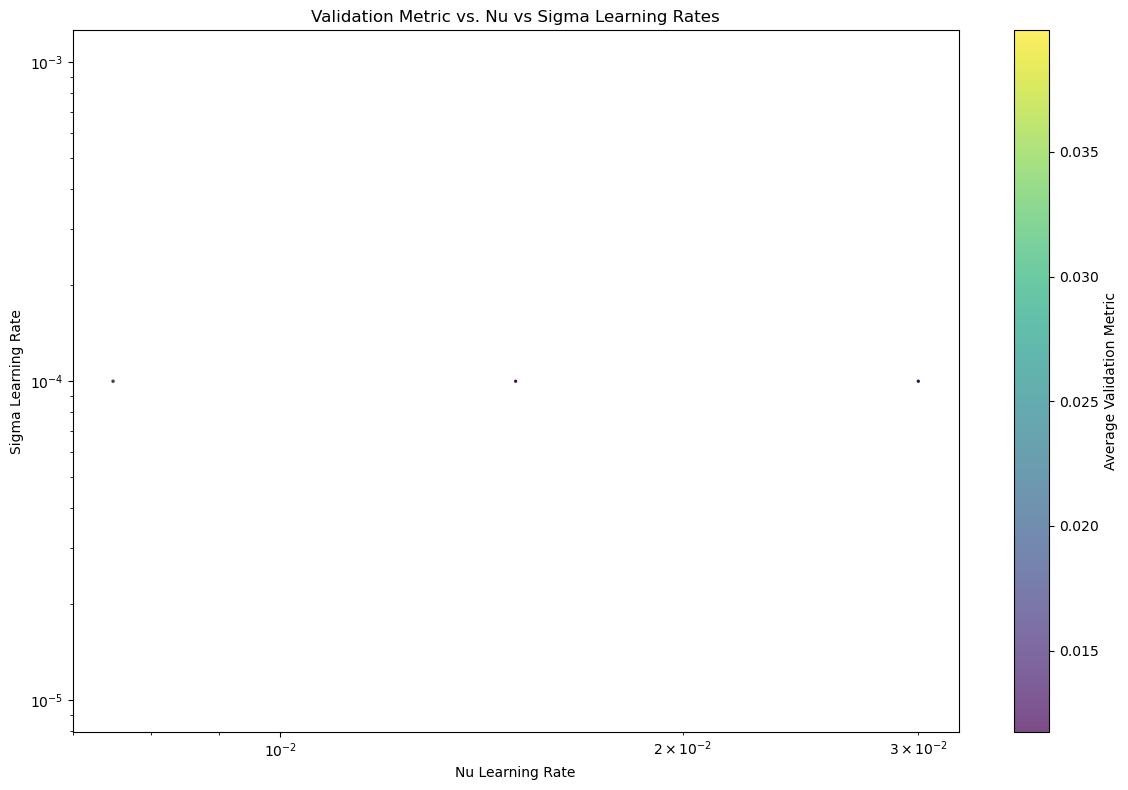

In [20]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

using_median = True # use the median (not average) of val metric over data sets

# Base directory with '~' expanded
base_dir = os.path.expanduser('~/project/43_estimation_results')

# Initialize lists to store data for plotting
alpha_lr_vals = []
nu_lr_vals = []
sigma_lr_vals = []
alpha_init_vals = []
nu_init_vals = []
sigma_init_vals = []
average_validation_metrics = []
median_validation_metrics = []

# Get all hyperparameter files
hyperparam_files = sorted(glob.glob(os.path.join(base_dir, 'hyperparameters_*.csv')))

print("Hyperparam | Ave metric | Median metric")

for hyperparam_file in hyperparam_files:
    # Extract 'l' from the filename
    l = os.path.splitext(os.path.basename(hyperparam_file))[0].split('_')[-1]
    l = int(l)
    # if l ==45:
    #     break

    # Read hyperparameters with headers
    hyperparams_df = pd.read_csv(hyperparam_file)

    # Extract individual learning rate and initialization values
    alpha_lr = hyperparams_df['alpha_lr'].iloc[0]
    nu_lr = hyperparams_df['nu_lr'].iloc[0]
    sigma_lr = hyperparams_df['sigma_lr'].iloc[0]
    alpha_init = hyperparams_df['alpha_init'].iloc[0]
    nu_init = hyperparams_df['nu_init'].iloc[0]
    sigma_init = hyperparams_df['sigma_init'].iloc[0]
    val_metric_file_path = f"{base_dir}/validation_metric_hyperparam_{l}.csv"
    
    if os.path.exists(val_metric_file_path):
        df = pd.read_csv(val_metric_file_path, header=None, names=["metric", "value"])
    else:
        print(val_metric_file_path, " does not exist.")
        continue
        
    # Convert the "value" column to the appropriate data types
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    average_validation_metric = df.loc[df["metric"] == "average_validation_metric", "value"].iloc[0]
    median_validation_metric = df.loc[df["metric"] == "median_validation_metric", "value"].iloc[0]
    
    print(l,average_validation_metric,median_validation_metric)

    # Append to the master lists
    alpha_lr_vals.append(alpha_lr)
    nu_lr_vals.append(nu_lr)
    sigma_lr_vals.append(sigma_lr)
    alpha_init_vals.append(alpha_init)
    nu_init_vals.append(nu_init)
    sigma_init_vals.append(sigma_init)
    average_validation_metrics.append(average_validation_metric)
    median_validation_metrics.append(median_validation_metric)
    

# Convert average validation metrics to a numpy array for color scaling
if using_median:
    validation_metrics = np.array(median_validation_metrics)
else:
    validation_metrics = np.array(average_validation_metrics)
    
# Plotting Alpha Learning Rate vs. Alpha Initialization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    alpha_lr_vals,
    alpha_init_vals,
    s=validation_metrics * 100,  # Adjust marker size based on validation metric
    c=validation_metrics,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Alpha Learning Rate')
plt.ylabel('Alpha Initialization')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Alpha Hyperparameters')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Validation Metric')
plt.show()

# Plotting Nu Learning Rate vs. Nu Initialization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    nu_lr_vals,
    nu_init_vals,
    s=validation_metrics * 100,  # Adjust marker size based on validation metric
    c=validation_metrics,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Nu Learning Rate')
plt.ylabel('Nu Initialization')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Nu Hyperparameters')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Validation Metric')
plt.show()

# Plotting Sigma Learning Rate vs. Sigma Initialization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    sigma_lr_vals,
    sigma_init_vals,
    s=validation_metrics * 100,  # Adjust marker size based on validation metric
    c=validation_metrics,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Sigma Learning Rate')
plt.ylabel('Sigma Initialization')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Sigma Hyperparameters')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Validation Metric')
plt.show()

# Scatter plot for Alpha Learning Rate vs. Nu Learning Rate
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    alpha_lr_vals,
    nu_lr_vals,
    s=validation_metrics * 100,  # Adjust marker size based on validation metric
    c=validation_metrics,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Alpha Learning Rate')
plt.ylabel('Nu Learning Rate')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Alpha vs Nu Learning Rates')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Validation Metric')
plt.show()

# Scatter plot for Alpha Learning Rate vs. Sigma Learning Rate
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    alpha_lr_vals,
    sigma_lr_vals,
    s=validation_metrics * 100,  # Adjust marker size based on validation metric
    c=validation_metrics,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Alpha Learning Rate')
plt.ylabel('Sigma Learning Rate')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Alpha vs Sigma Learning Rates')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Validation Metric')
plt.show()

# Scatter plot for Nu Learning Rate vs. Sigma Learning Rate
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    nu_lr_vals,
    sigma_lr_vals,
    s=validation_metrics * 100,  # Adjust marker size based on validation metric
    c=validation_metrics,
    cmap='viridis',
    alpha=0.7
)
plt.xlabel('Nu Learning Rate')
plt.ylabel('Sigma Learning Rate')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Nu vs Sigma Learning Rates')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Validation Metric')
plt.tight_layout()
plt.show()

In [21]:
alpha_lr_vals

[0.002, 0.002, 0.002, 0.001, 0.001, 0.001, 0.0005, 0.0005, 0.0005]

In [22]:
validation_metrics

array([0.02179659, 0.01349899, 0.03987511, 0.01199924, 0.01229959,
       0.01818336, 0.01179194, 0.011729  , 0.01460863])

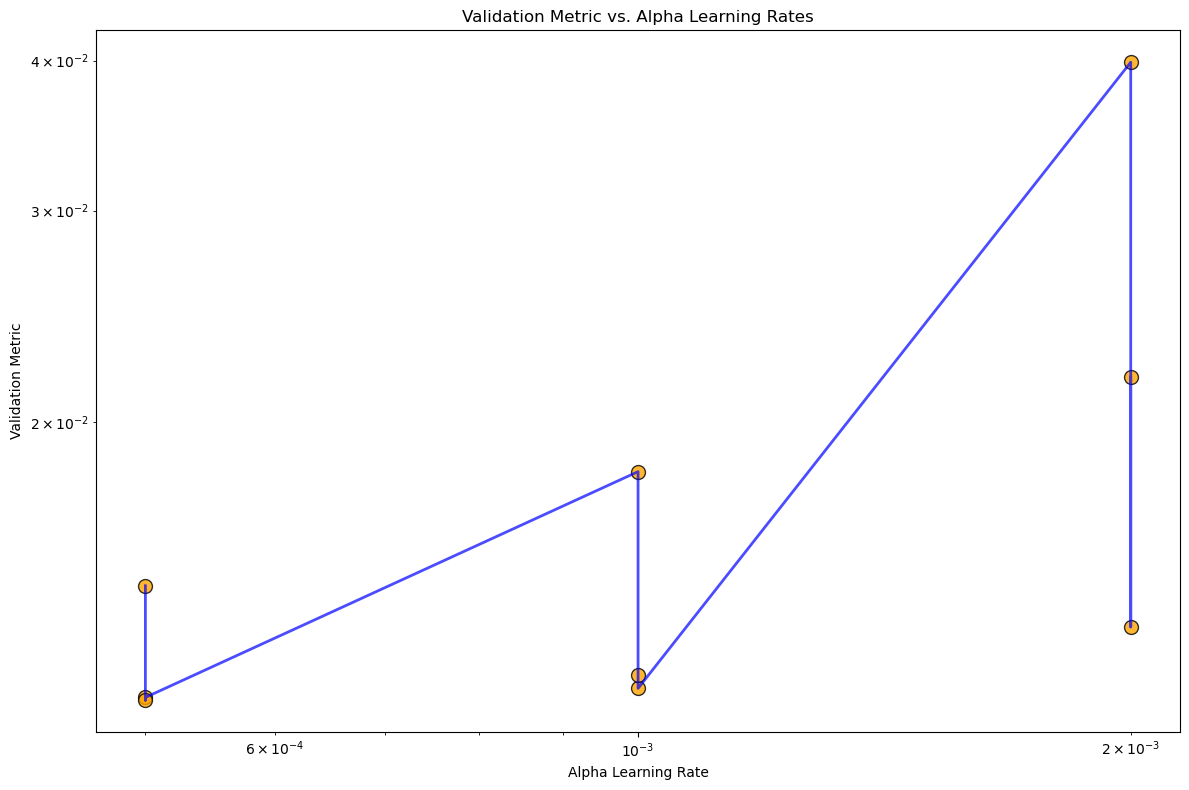

In [23]:
plt.figure(figsize=(12, 8))
plt.plot(
    alpha_lr_vals,
    validation_metrics,
    linestyle = "-",
    linewidth = 2,
    color = "blue",
    label = 'Average Validation Metric',
    alpha=0.7
)
plt.scatter(
    alpha_lr_vals,
    validation_metrics,
    s=100,
    edgecolor="black",
    linewidth=1,
    color = "orange",
    alpha = 0.8,
    label = "Data Points"
)
plt.xlabel('Alpha Learning Rate')
plt.ylabel('Validation Metric')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Alpha Learning Rates')
plt.tight_layout()
plt.show()

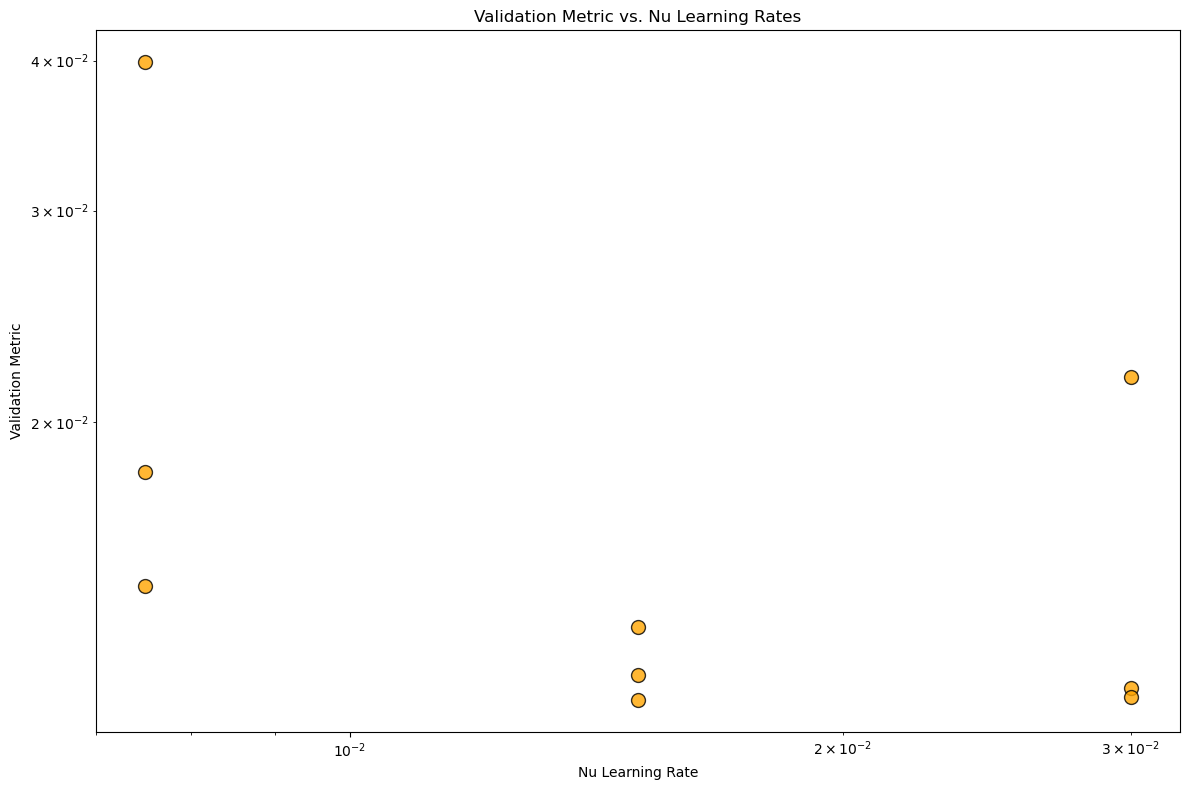

In [27]:
plt.figure(figsize=(12, 8))
# plt.plot(
#     nu_lr_vals,
#     validation_metrics,
#     linestyle = "-",
#     linewidth = 2,
#     color = "blue",
#     label = 'Average Validation Metric',
#     alpha=0.7
# )
plt.scatter(
    nu_lr_vals,
    validation_metrics,
    s=100,
    edgecolor="black",
    linewidth=1,
    color = "orange",
    alpha = 0.8,
    label = "Data Points"
)
plt.xlabel('Nu Learning Rate')
plt.ylabel('Validation Metric')
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.title('Validation Metric vs. Nu Learning Rates')
plt.tight_layout()
plt.show()

In [5]:
average_validation_metrics

[0.1060581320367335,
 0.1005771292809787,
 0.1186063389552488,
 0.0988624932492358,
 0.0987748751003817,
 0.1044014871216504,
 0.0982178095605815,
 0.0983259266534038,
 0.1002862621956511]

In [6]:
median_validation_metrics

[0.0217965913758308,
 0.0134989897920653,
 0.0398751082074255,
 0.0119992443507266,
 0.0122995896362846,
 0.0181833599699688,
 0.0117919366133042,
 0.0117289966315979,
 0.0146086340208372]

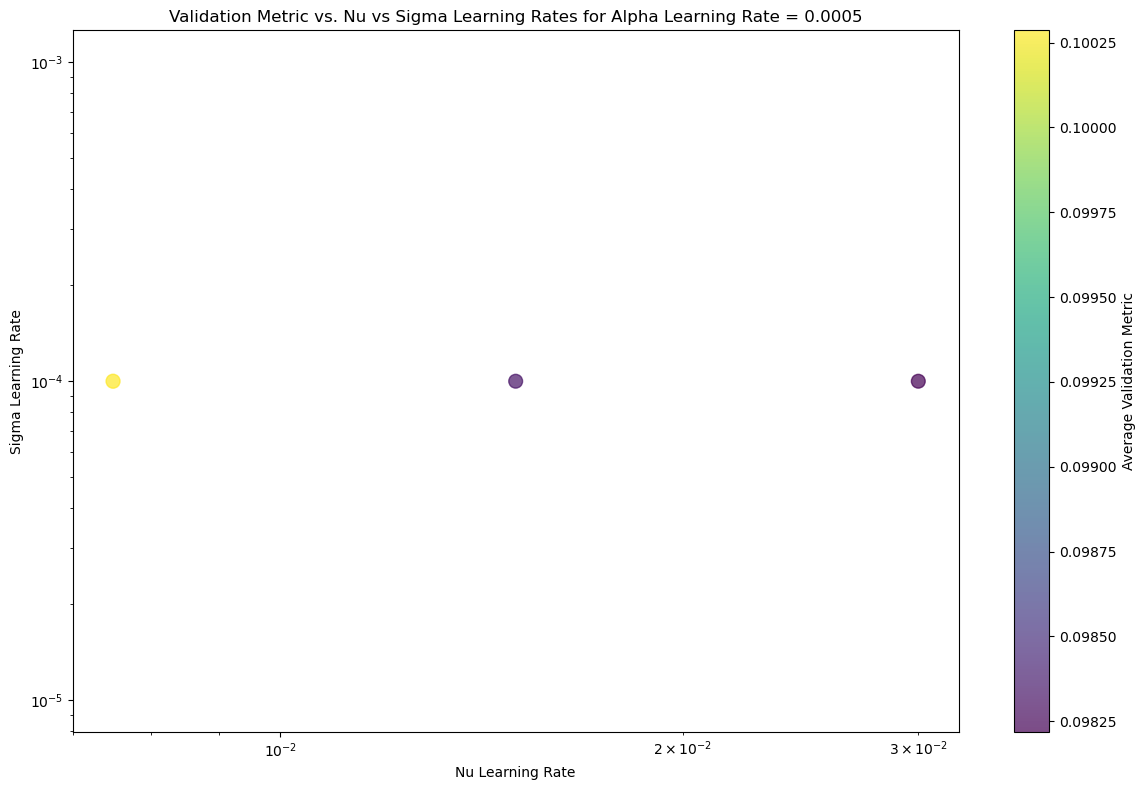

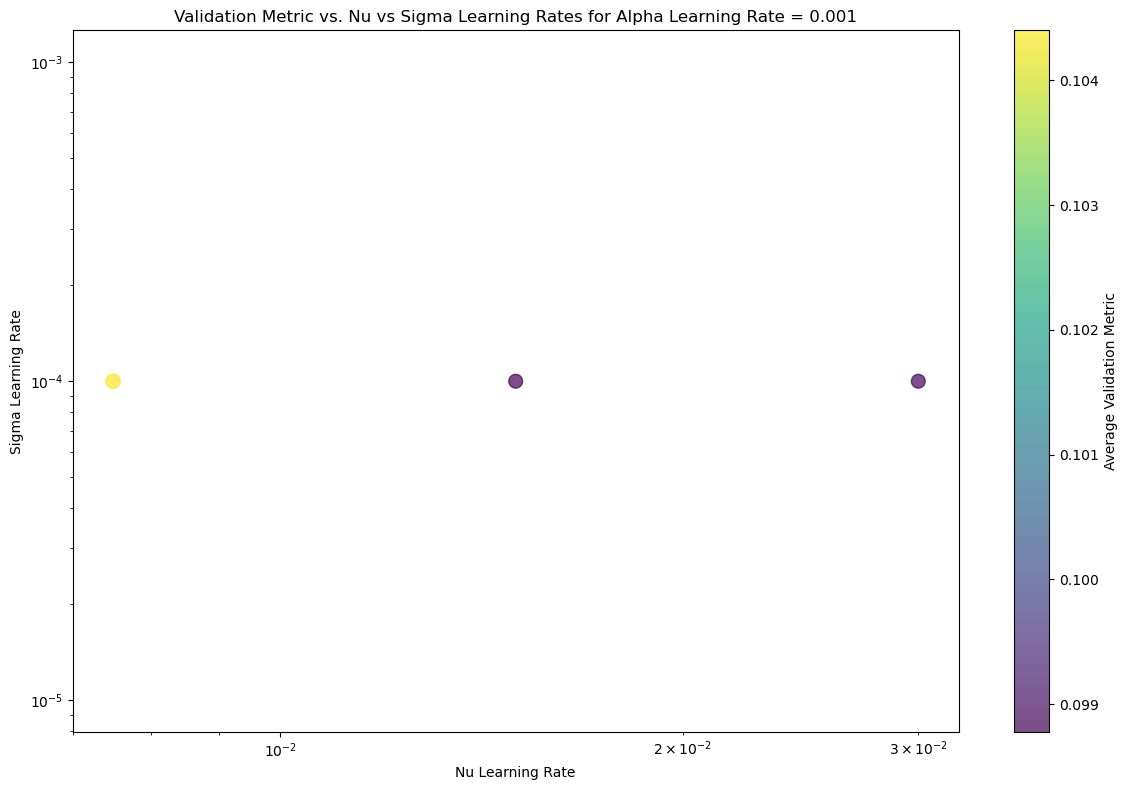

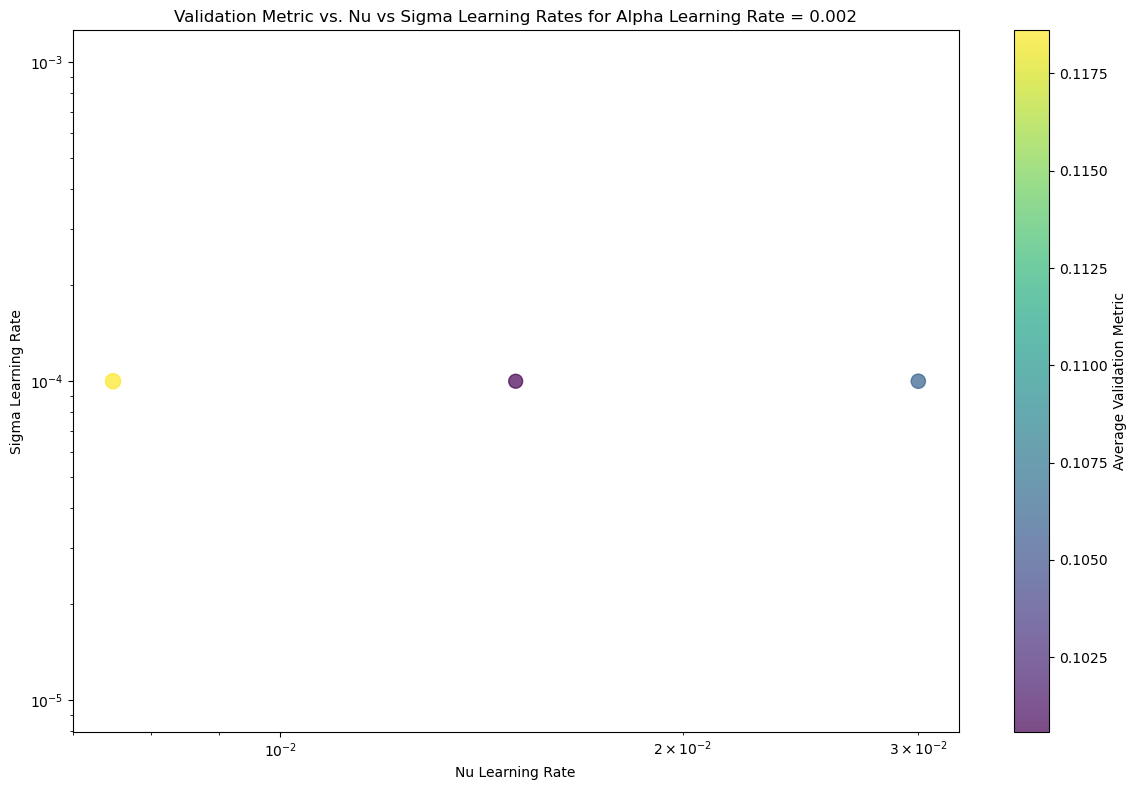

In [14]:
# Convert lists to numpy arrays for easy filtering (for specific operations)
alpha_lr_vals = np.array(alpha_lr_vals)
nu_lr_vals = np.array(nu_lr_vals)
sigma_lr_vals = np.array(sigma_lr_vals)
average_validation_metrics = np.array(average_validation_metrics)

# Loop through each unique alpha_lr
unique_alpha_lr_vals = np.unique(alpha_lr_vals)
for alpha_lr in unique_alpha_lr_vals:
    # Filter data for the current alpha_lr value
    indices = (alpha_lr_vals == alpha_lr)  # Boolean mask for current alpha_lr

    # Ensure that there are valid entries for the current alpha_lr
    if np.sum(indices) == 0:
        continue

    # Scatter plot for Nu Learning Rate vs. Sigma Learning Rate
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        np.array(nu_lr_vals)[indices],
        np.array(sigma_lr_vals)[indices],
        s=np.array(average_validation_metrics)[indices] * 1000,
        c=np.array(average_validation_metrics)[indices],
        cmap='viridis',
        alpha=0.7
    )
    plt.xlabel('Nu Learning Rate')
    plt.ylabel('Sigma Learning Rate')
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Validation Metric vs. Nu vs Sigma Learning Rates for Alpha Learning Rate = {alpha_lr}')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Average Validation Metric')
    plt.tight_layout()  # Adjust layout
    plt.show()

In [8]:
print("alpha  nu   sigma")
for a,b,c in zip(alpha_lr_vals, nu_lr_vals, sigma_lr_vals):
    print(a,b,c)



alpha  nu   sigma
0.002 0.03 0.0001
0.002 0.015 0.0001
0.002 0.0075 0.0001
0.001 0.03 0.0001
0.001 0.015 0.0001
0.001 0.0075 0.0001
0.0005 0.03 0.0001
0.0005 0.015 0.0001
0.0005 0.0075 0.0001


In [9]:
import os
import glob
import pandas as pd
import numpy as np

# Base directory with '~' expanded
base_dir = os.path.expanduser('~/project/43_estimation_results')

# Initialize lists to store data for debugging
alpha_lr_vals = []
nu_lr_vals = []
sigma_lr_vals = []
alpha_init_vals = []
nu_init_vals = []
sigma_init_vals = []
average_validation_metrics = []

# Get all hyperparameter files
hyperparam_files = sorted(glob.glob(os.path.join(base_dir, 'hyperparameters_*.csv')))

for hyperparam_file in hyperparam_files:
    # print(f"Processing file: {hyperparam_file}")
    
    # Extract 'l' from the filename
    l_str = os.path.splitext(os.path.basename(hyperparam_file))[0].split('_')[-1]
    l = int(l_str)
    # print("file ",l)
    if l==45:
        break

    # Read hyperparameters with headers
    hyperparams_df = pd.read_csv(hyperparam_file)

    # Extract individual learning rate and initialization values
    alpha_lr = hyperparams_df['alpha_lr'].iloc[0]
    nu_lr = hyperparams_df['nu_lr'].iloc[0]
    sigma_lr = hyperparams_df['sigma_lr'].iloc[0]
    alpha_init = hyperparams_df['alpha_init'].iloc[0]
    nu_init = hyperparams_df['nu_init'].iloc[0]
    sigma_init = hyperparams_df['sigma_init'].iloc[0]

    # print(f"Hyperparameters extracted - alpha_lr: {alpha_lr}, nu_lr: {nu_lr}, sigma_lr: {sigma_lr}, alpha_init: {alpha_init}, nu_init: {nu_init}, sigma_init: {sigma_init}")

    # Read validation metrics for each feature j
    validation_metrics = []
    for j in range(3):
        validation_metric_file = os.path.join(
            base_dir, f'validation_metric_hyperparam_{l}_feature_{j}.csv'
        )
        # print(f"Processing validation metric file: {validation_metric_file}")
        
        # Read the validation metric CSV with headers
        validation_metric_df = pd.read_csv(validation_metric_file)

        # Check for presence of 'average' row
        avg_row = validation_metric_df[validation_metric_df['data set i'] == 'average']
        if avg_row.empty:
            print(f"Warning: No 'average' row found in {validation_metric_file}")
            continue

        # Extract the average validation metric value
        avg_validation_metric = avg_row['validation_metric'].astype(float).values[0]
        # print(f"Feature {j} - Average validation metric: {avg_validation_metric}")
        
        validation_metrics.append(avg_validation_metric)

    # Compute the overall average validation metric for this hyperparameter set
    if validation_metrics:
        overall_avg_validation_metric = np.nan_to_num(np.mean(validation_metrics), nan=0.0)
        # print(f"Overall average validation metric: {overall_avg_validation_metric}")
    else:
        print("Warning: No valid validation metrics found, setting overall average validation metric to 0")
        overall_avg_validation_metric = 0.0

    # Append to lists for potential plotting (not plotting here)
    alpha_lr_vals.append(alpha_lr)
    nu_lr_vals.append(nu_lr)
    sigma_lr_vals.append(sigma_lr)
    alpha_init_vals.append(alpha_init)
    nu_init_vals.append(nu_init)
    sigma_init_vals.append(sigma_init)
    average_validation_metrics.append(overall_avg_validation_metric)
    if overall_avg_validation_metric < 0.6:
        print("file", l)
        print("metric", overall_avg_validation_metric)
        print("alpha lr", alpha_lr)
        print("nu lr", nu_lr)
        print("sigma lr", sigma_lr)
        print("\n")
        
# print("\nDebugging summary:")
# print("Alpha LRs:", alpha_lr_vals)
# print("Nu LRs:", nu_lr_vals)
# print("Sigma LRs:", sigma_lr_vals)
# print("Alpha Inits:", alpha_init_vals)
# print("Nu Inits:", nu_init_vals)
# print("Sigma Inits:", sigma_init_vals)
# print("Average Validation Metrics:", average_validation_metrics)

file 0
metric 0.10605813203673357
alpha lr 0.002
nu lr 0.03
sigma lr 0.0001


file 1
metric 0.10057712928097874
alpha lr 0.002
nu lr 0.015
sigma lr 0.0001


file 2
metric 0.1186063389552488
alpha lr 0.002
nu lr 0.0075
sigma lr 0.0001


file 3
metric 0.09886249324923585
alpha lr 0.001
nu lr 0.03
sigma lr 0.0001


file 4
metric 0.09877487510038169
alpha lr 0.001
nu lr 0.015
sigma lr 0.0001


file 5
metric 0.10440148712165043
alpha lr 0.001
nu lr 0.0075
sigma lr 0.0001


file 6
metric 0.09821780956058153
alpha lr 0.0005
nu lr 0.03
sigma lr 0.0001


file 7
metric 0.09832592665340385
alpha lr 0.0005
nu lr 0.015
sigma lr 0.0001


file 8
metric 0.10028626219565116
alpha lr 0.0005
nu lr 0.0075
sigma lr 0.0001




## to create some more hyperparameters

In [10]:
# # Base values for each hyperparameter
# base_hyperparameters = {
#     'alpha_lr': 0.002,
#     'nu_lr': 0.03,
#     'sigma_lr': 1.0,
#     'alpha_init': 0.01,
#     'nu_init': 1.0,
#     'sigma_init': 1.0
# }

# # Define perturbation ranges (adjust as needed for your search scope)
# perturbation_ranges = {
#     'alpha_lr': 0.001,  # +/- 0.001 around base value
#     'nu_lr': 0.01,      # +/- 0.01 around base value
#     'sigma_lr': 0.1,    # +/- 0.1 around base value
#     'alpha_init': 0.005, # +/- 0.005 around base value
#     'nu_init': 0.1,     # +/- 0.1 around base value
#     'sigma_init': 0.0  # fixed
# }

# # Generate 30 perturbed sets
# num_perturbations = 30
# learning_rates = []
# initializations = []

# for _ in range(num_perturbations):
#     # Generate perturbed learning rates
#     perturbed_learning_rates = {
#         'alpha_lr': base_hyperparameters['alpha_lr'] + np.random.uniform(-perturbation_ranges['alpha_lr'], perturbation_ranges['alpha_lr']),
#         'nu_lr': base_hyperparameters['nu_lr'] + np.random.uniform(-perturbation_ranges['nu_lr'], perturbation_ranges['nu_lr']),
#         'sigma_lr': base_hyperparameters['sigma_lr'] + np.random.uniform(-perturbation_ranges['sigma_lr'], perturbation_ranges['sigma_lr'])
#     }
    
#     # Generate perturbed initialization values
#     perturbed_initializations = {
#         'alpha_init': base_hyperparameters['alpha_init'] + np.random.uniform(-perturbation_ranges['alpha_init'], perturbation_ranges['alpha_init']),
#         'nu_init': base_hyperparameters['nu_init'] + np.random.uniform(-perturbation_ranges['nu_init'], perturbation_ranges['nu_init']),
#         'sigma_init': base_hyperparameters['sigma_init'] + np.random.uniform(-perturbation_ranges['sigma_init'], perturbation_ranges['sigma_init'])
#     }
    
#     # Append to lists
#     learning_rates.append(perturbed_learning_rates)
#     initializations.append(perturbed_initializations)

# # Print the generated sets
# print("Learning Rates:")
# print(learning_rates)
# print("\nInitializations:")
# print(initializations)
# learning_rates

In [11]:
initializations

NameError: name 'initializations' is not defined

## Figure out the main problems in estimation

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Base directory
base_dir = os.path.expanduser('~/project/43_estimation_results')

# Lists to store values for alpha, nu, and sigma
alpha_vals = []
nu_vals = []
sigma_vals = []

# Use glob to match files with the pattern
file_pattern = os.path.join(base_dir, '*', 'best_parameters_dataset_*_feature_0.csv')
files = glob.glob(file_pattern)

# Loop over all matched files
for file_path in files:
    try:
        # Read CSV file
        df = pd.read_csv(file_path)
        # Extract alpha, nu, sigma values
        alpha_vals.append(df['alpha'].iloc[0])
        nu_vals.append(df['nu'].iloc[0])
        sigma_vals.append(df['sigma'].iloc[0])
    except (FileNotFoundError, pd.errors.EmptyDataError, KeyError):
        print(f"Skipping file due to missing data or formatting issues: {file_path}")
        continue

# Plot histograms for alpha, nu, and sigma
plt.figure(figsize=(12, 4))

# Alpha Histogram
plt.subplot(1, 3, 1)
plt.hist(alpha_vals, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Alpha')
plt.ylabel('Frequency')
plt.title('Histogram of Alpha')

# Nu Histogram
plt.subplot(1, 3, 2)
plt.hist(nu_vals, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Nu')
plt.ylabel('Frequency')
plt.title('Histogram of Nu')

# Sigma Histogram
plt.subplot(1, 3, 3)
plt.hist(sigma_vals, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Sigma')
plt.ylabel('Frequency')
plt.title('Histogram of Sigma')

plt.tight_layout()
plt.show()